In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

df = pd.read_csv('Sleep_health_and_lifestyle_dataset.csv')

print("Eksik Değerler:\n", df.isnull().sum())
print("\nVeri Tipleri:\n", df.dtypes)

Eksik Değerler:
 Person ID                    0
Gender                       0
Age                          0
Occupation                   0
Sleep Duration               0
Quality of Sleep             0
Physical Activity Level      0
Stress Level                 0
BMI Category                 0
Blood Pressure               0
Heart Rate                   0
Daily Steps                  0
Sleep Disorder             219
dtype: int64

Veri Tipleri:
 Person ID                    int64
Gender                      object
Age                          int64
Occupation                  object
Sleep Duration             float64
Quality of Sleep             int64
Physical Activity Level      int64
Stress Level                 int64
BMI Category                object
Blood Pressure              object
Heart Rate                   int64
Daily Steps                  int64
Sleep Disorder              object
dtype: object


In [ ]:

df['Sleep Disorder'] = df['Sleep Disorder'].fillna('None')

df[['Systolic_BP', 'Diastolic_BP']] = df['Blood Pressure'].str.split('/', expand=True).astype(int)

df.drop(['Blood Pressure', 'Person ID'], axis=1, inplace=True)

print("Veri başarıyla temizlendi! Artık modelin anlayacağı sayısal sütunlarımız var.")
print(df.head())

Veri başarıyla temizlendi! Artık modelin anlayacağı sayısal sütunlarımız var.
  Gender  Age            Occupation  Sleep Duration  Quality of Sleep  \
0   Male   27     Software Engineer             6.1                 6   
1   Male   28                Doctor             6.2                 6   
2   Male   28                Doctor             6.2                 6   
3   Male   28  Sales Representative             5.9                 4   
4   Male   28  Sales Representative             5.9                 4   

   Physical Activity Level  Stress Level BMI Category  Heart Rate  \
0                       42             6   Overweight          77   
1                       60             8       Normal          75   
2                       60             8       Normal          75   
3                       30             8        Obese          85   
4                       30             8        Obese          85   

   Daily Steps Sleep Disorder  Systolic_BP  Diastolic_BP  
0        

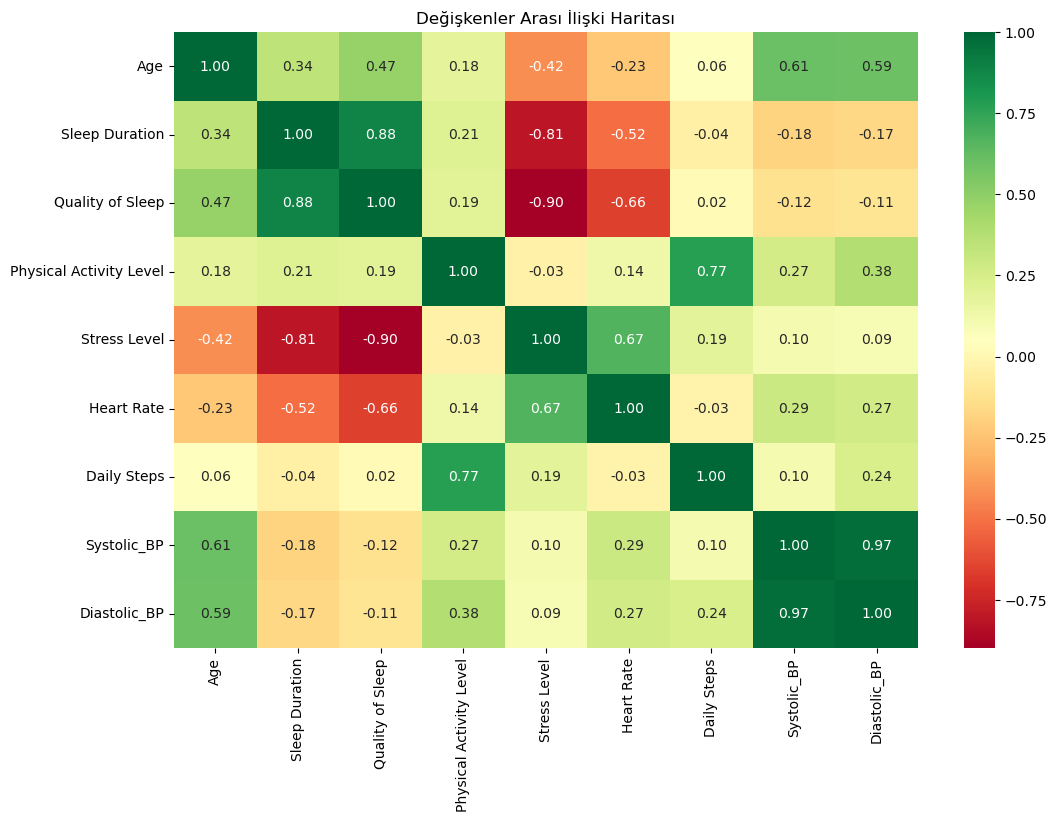

C:\Users\Asus\AppData\Local\Temp\ipykernel_27068\852935957.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Quality of Sleep', y='Stress Level', data=df, palette='viridis')


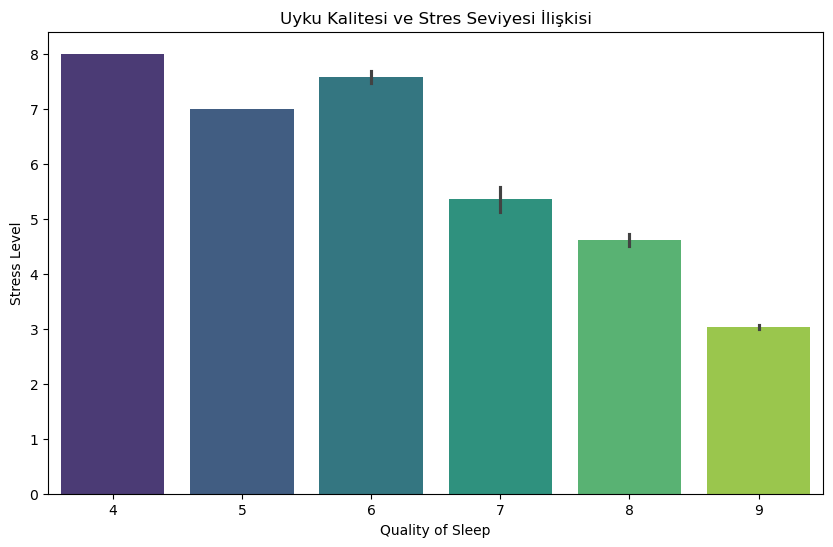

In [ ]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='RdYlGn', fmt='.2f')
plt.title('Değişkenler Arası İlişki Haritası')
plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(x='Quality of Sleep', y='Stress Level', data=df, palette='viridis')
plt.title('Uyku Kalitesi ve Stres Seviyesi İlişkisi')
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

le = LabelEncoder()
cat_cols = ['Gender', 'Occupation', 'BMI Category', 'Sleep Disorder']
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

df['Target'] = df['Quality of Sleep'].apply(lambda x: 1 if x >= 7 else 0)

X = df.drop(['Quality of Sleep', 'Target'], axis=1)
y = df['Target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("X_train başarıyla oluşturuldu. Artık model eğitme aşamasına hazırsın!")

X_train başarıyla oluşturuldu. Artık model eğitme aşamasına hazırsın!


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

models = {
    "Logistic Regression (Baseline)": LogisticRegression(max_iter=1000),
    "Decision Tree (Intermediate)": DecisionTreeClassifier(random_state=42),
    "Random Forest (Advanced)": RandomForestClassifier(n_estimators=100, random_state=42)
}

from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(name)
    plt.show()

--- Logistic Regression (Baseline) Sonuçları ---
Doğruluk (Accuracy) Skoru: 0.99
              precision    recall  f1-score   support

           0       0.97      1.00      0.98        29
           1       1.00      0.98      0.99        46

    accuracy                           0.99        75
   macro avg       0.98      0.99      0.99        75
weighted avg       0.99      0.99      0.99        75

------------------------------
--- Decision Tree (Intermediate) Sonuçları ---
Doğruluk (Accuracy) Skoru: 1.00
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        29
           1       1.00      1.00      1.00        46

    accuracy                           1.00        75
   macro avg       1.00      1.00      1.00        75
weighted avg       1.00      1.00      1.00        75

------------------------------
--- Random Forest (Advanced) Sonuçları ---
Doğruluk (Accuracy) Skoru: 1.00
              precision    recall  f1-score   sup

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier 

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

cv_scores = cross_val_score(rf_model, X, y, cv=5)

print(f"Her bir fold için skorlar: {cv_scores}")
print(f"Ortalama Doğruluk: {cv_scores.mean():.4f}")
print(f"Standart Sapma: {cv_scores.std():.4f}")

Her bir fold için skorlar: [1.         1.         0.98666667 0.90666667 1.        ]
Ortalama Doğruluk: 0.9787
Standart Sapma: 0.0364
